# Cluster-Based Undersampling with FDUS Method

This notebook implements two approaches for handling extremely imbalanced datasets (fraud rate ~0.003%):

1. **Traditional Cluster-Based Undersampling**: K-Means and DBSCAN clustering with proportional sampling
2. **FDUS (Fitting Data Distribution with UnderSampling)**: Novel method from Zhou et al. (2024) that approaches the ideal classification boundary

## Key Features of FDUS:
- Clusters majority class samples using K-Means
- Performs **spatial compression** to focus on boundary regions
- Uses **weighted sampling** where points closer to decision boundary have higher probability of selection
- Employs **ensemble learning** with optimal classifier count determination

**Reference**: Zhou, W., Liu, C., Yuan, P., & Jiang, L. (2024). "An Undersampling Method Approaching the Ideal Classification Boundary for Imbalance Problems." Applied Sciences, 14(13), 5421.

This script takes XX Minutes to run on the unified dataset.

In [ ]:
##############################################################################
# IMPORTS AND CONFIGURATION
##############################################################################
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.cluster import DBSCAN, KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score, f1_score,
    roc_curve
)

from scipy.spatial import ConvexHull
from scipy.stats import shapiro

# Silence warning noise
warnings.filterwarnings("ignore")

# Expand column display for wide feature tables
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries loaded successfully")


Dataset Shape: 140,827 rows x 140 columns

Fraud Distribution:
target
0    140771
1        56
Name: count, dtype: int64

Fraud Rate: 0.0398%
Approximately 1 fraud per 2,514 transactions


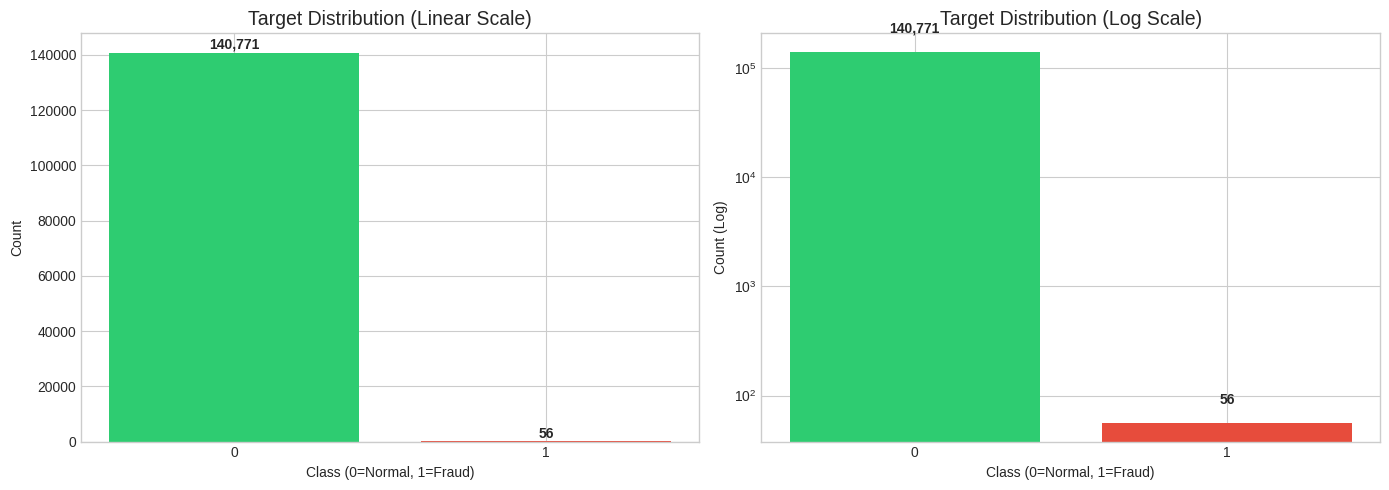


Imbalance Ratio: 2514:1 (Majority:Minority)


In [2]:
##############################################################################
# DATA LOADING AND PREPROCESSING
##############################################################################
df = pd.read_csv("/dsa/groups/casestudycf25/team02/gold/unified_dataset.csv")

print(f"Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nFraud Distribution:")
print(df['target'].value_counts())

fraud_rate = df['target'].mean()
print(f"\nFraud Rate: {fraud_rate:.4%}")
print(f"Approximately 1 fraud per {int(1/fraud_rate):,} transactions")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['target'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(class_counts.index.astype(str), class_counts.values, color=colors)
axes[0].set_title("Target Distribution (Linear Scale)", fontsize=14)
axes[0].set_xlabel("Class (0=Normal, 1=Fraud)")
axes[0].set_ylabel("Count")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + max(class_counts.values)*0.01, f'{v:,}', ha='center', fontweight='bold')

axes[1].bar(class_counts.index.astype(str), class_counts.values, color=colors)
axes[1].set_title("Target Distribution (Log Scale)", fontsize=14)
axes[1].set_xlabel("Class (0=Normal, 1=Fraud)")
axes[1].set_ylabel("Count (Log)")
axes[1].set_yscale('log')
for i, v in enumerate(class_counts.values):
    axes[1].text(i, v * 1.5, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

imbalance_ratio = class_counts[0] / class_counts[1]
print(f"\nImbalance Ratio: {imbalance_ratio:.0f}:1 (Majority:Minority)")


In [3]:
##############################################################################
# FEATURE PREPARATION
##############################################################################
exclude_cols = [
    'npi', 'rfrg_prvdr_state_abrvtn', 'year', 'target', 
    'og_specialty_name', 'first_payment_date', 'last_payment_date',
    'specialty_type', 'specialty'
]
exclude_cols = list(dict.fromkeys(exclude_cols))

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in exclude_cols]

print(f"Number of features kept: {len(feature_cols)}")

df_clean = df[feature_cols + ['target']].dropna()
print(f"Samples after dropping NaN: {len(df_clean):,}")

X = df_clean[feature_cols].values
y = df_clean['target'].values

print(f"\nClass Distribution:")
print(f"  Non-Fraud (0): {(y == 0).sum():,}")
print(f"  Fraud (1): {(y == 1).sum():,}")


Number of features kept: 106
Samples after dropping NaN: 140,827

Class Distribution:
  Non-Fraud (0): 140,771
  Fraud (1): 56


## Train/Test Split


In [4]:
##############################################################################
# TRAIN/TEST SPLIT (BEFORE UNDERSAMPLING) - GROUP BY NPI
##############################################################################
# Group-based split: All rows with the same NPI stay together in train or test
# This prevents data leakage where a provider's patterns appear in both sets

from sklearn.model_selection import GroupShuffleSplit

# Get unique NPIs and their fraud status
npi_fraud_status = df.groupby('npi')['target'].max().reset_index()
npi_fraud_status.columns = ['npi', 'has_fraud']

# Separate fraud and non-fraud NPIs
fraud_npis = npi_fraud_status[npi_fraud_status['has_fraud'] == 1]['npi'].values
nonfraud_npis = npi_fraud_status[npi_fraud_status['has_fraud'] == 0]['npi'].values

print(f"Total unique NPIs: {len(npi_fraud_status):,}")
print(f"NPIs with fraud: {len(fraud_npis)}")
print(f"NPIs without fraud: {len(nonfraud_npis):,}")

# Stratified group split: ensure fraud NPIs are split proportionally
np.random.seed(69)
np.random.shuffle(fraud_npis)
np.random.shuffle(nonfraud_npis)

# Split fraud NPIs (80/20)
n_fraud_train = int(len(fraud_npis) * 0.8)
fraud_npis_train = fraud_npis[:n_fraud_train]
fraud_npis_test = fraud_npis[n_fraud_train:]

# Split non-fraud NPIs (80/20)
n_nonfraud_train = int(len(nonfraud_npis) * 0.8)
nonfraud_npis_train = nonfraud_npis[:n_nonfraud_train]
nonfraud_npis_test = nonfraud_npis[n_nonfraud_train:]

# Combine
train_npis = np.concatenate([fraud_npis_train, nonfraud_npis_train])
test_npis = np.concatenate([fraud_npis_test, nonfraud_npis_test])

# Create train and test sets
train_mask = df['npi'].isin(train_npis)
test_mask = df['npi'].isin(test_npis)

df_train = df[train_mask].copy()
df_test = df[test_mask].copy()

X_train = df_train[feature_cols].values
y_train = df_train['target'].values
X_test = df_test[feature_cols].values
y_test = df_test['target'].values

print(f"\nTraining set: {len(X_train):,} samples from {len(train_npis):,} NPIs")
print(f"  Non-Fraud: {(y_train == 0).sum():,}")
print(f"  Fraud: {(y_train == 1).sum()}")
print(f"\nTest set: {len(X_test):,} samples from {len(test_npis):,} NPIs")
print(f"  Non-Fraud: {(y_test == 0).sum():,}")
print(f"  Fraud: {(y_test == 1).sum()}")

# Verify no NPI overlap
train_npi_set = set(df_train['npi'].unique())
test_npi_set = set(df_test['npi'].unique())
overlap = train_npi_set.intersection(test_npi_set)
print(f"\nNPI overlap between train/test: {len(overlap)} (should be 0)")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Separate majority and minority
majority_idx = np.where(y_train == 0)[0]
minority_idx = np.where(y_train == 1)[0]

X_train_majority = X_train_scaled[majority_idx]
X_train_minority = X_train_scaled[minority_idx]

n_minority = len(minority_idx)
n_majority = len(majority_idx)

print(f"\nFeatures standardized")
print(f"  Minority samples: {n_minority}")
print(f"  Majority samples: {n_majority:,}")


Total unique NPIs: 63,117
NPIs with fraud: 23
NPIs without fraud: 63,094

Training set: 112,540 samples from 50,493 NPIs
  Non-Fraud: 112,497
  Fraud: 43

Test set: 28,287 samples from 12,624 NPIs
  Non-Fraud: 28,274
  Fraud: 13

NPI overlap between train/test: 0 (should be 0)

Features standardized
  Minority samples: 43
  Majority samples: 112,497


PCA variance explained (50 components): 84.01%
2D projection variance explained: 45.22%


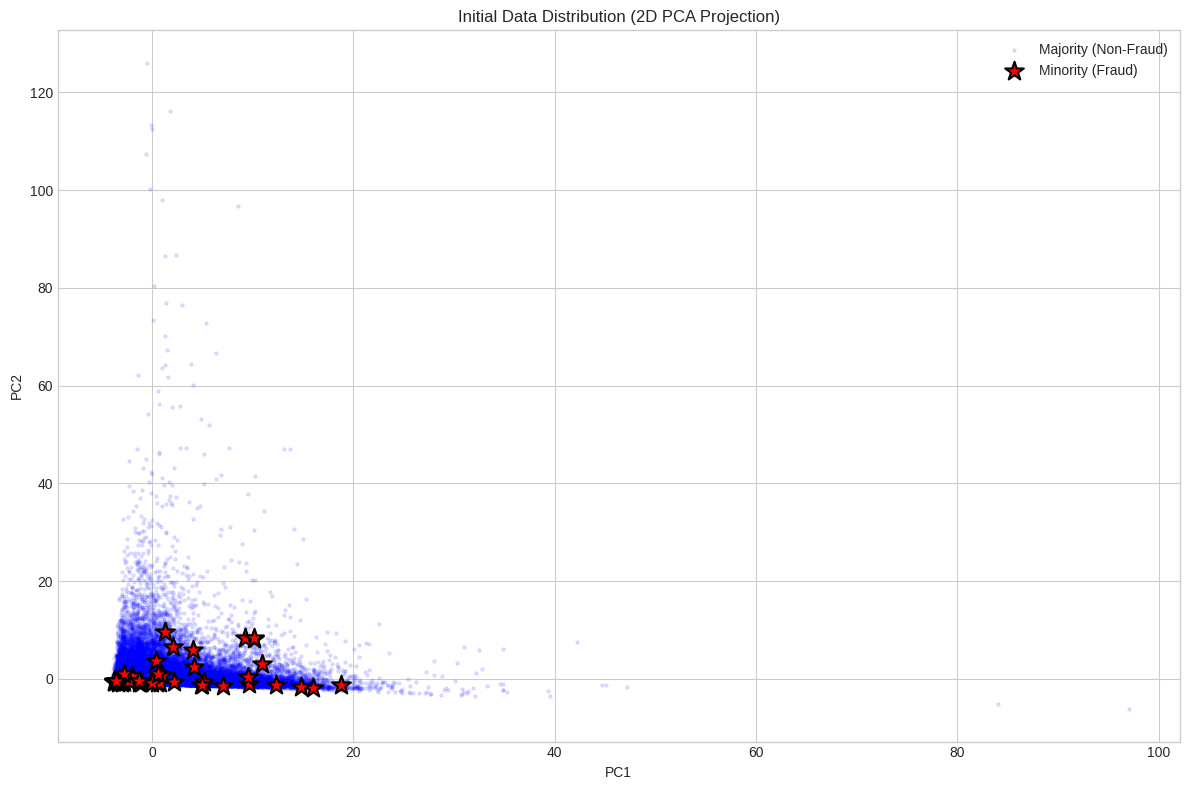

In [5]:
##############################################################################
# PCA FOR VISUALIZATION AND CLUSTERING
##############################################################################
# High-dimensional PCA for clustering
pca_components = min(50, X_train_majority.shape[1], X_train_majority.shape[0])
pca = PCA(n_components=pca_components)
X_train_majority_pca = pca.fit_transform(X_train_majority)
X_train_minority_pca = pca.transform(X_train_minority)

print(f"PCA variance explained ({pca_components} components): {pca.explained_variance_ratio_.sum():.2%}")

# 2D PCA for visualization
pca_2d = PCA(n_components=2)
X_majority_2d = pca_2d.fit_transform(X_train_majority_pca[:, :min(10, pca_components)])
X_minority_2d = pca_2d.transform(X_train_minority_pca[:, :min(10, pca_components)])

print(f"2D projection variance explained: {pca_2d.explained_variance_ratio_.sum():.2%}")

# Visualize initial data distribution
plt.figure(figsize=(12, 8))
plt.scatter(X_majority_2d[:, 0], X_majority_2d[:, 1], c='blue', alpha=0.1, s=5, label='Majority (Non-Fraud)')
plt.scatter(X_minority_2d[:, 0], X_minority_2d[:, 1], c='red', marker='*', s=200, 
            edgecolors='black', linewidths=1.5, label='Minority (Fraud)', zorder=10)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Initial Data Distribution (2D PCA Projection)')
plt.legend()
plt.tight_layout()
plt.show()


# FDUS: Fitting Data Distribution with UnderSampling

## Method Overview (Zhou et al., 2024)

The FDUS algorithm consists of three main steps:

### Step 1: Noise Filtering with kNN
- Remove noise samples that could affect classification

### Step 2: Weighted Undersampling based on Clustering (WUC)
1. Obtain initial separating hyperplane using linear classifier
2. Cluster majority class using K-Means
3. For each cluster, apply **spatial compression** (α < 1) to focus on boundary region
4. Apply **weighted sampling** where points closer to hyperplane have higher probability

### Step 3: Determine Optimal Number of Classifiers (DNC)
- Use ensemble learning with AdaBoost
- Find optimal number of classifiers that maximizes AUC
- Based on hypothesis that optimal classifier count exists in each learning cycle


In [6]:
##############################################################################
# FDUS IMPLEMENTATION
##############################################################################
import time

class FDUSUndersampler:
    """
    FDUS: Fitting Data Distribution with UnderSampling
    
    Based on Zhou et al. (2024). kNN noise filtering removed - ineffective 
    at extreme imbalance ratios (2600:1) where it removes 0 samples.
    """
    
    def __init__(self, n_clusters=7, alpha=0.5, target_ratio=5.0, random_state=42):
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.target_ratio = target_ratio
        self.random_state = random_state
        self.hyperplane_ = None
        self.cluster_model_ = None
        self.cluster_labels_ = None
    
    def _get_optimal_hyperplane(self, X, y):
        """Find separating hyperplane using logistic regression"""
        clf = LogisticRegression(max_iter=1000, random_state=self.random_state, solver='saga', n_jobs=-1)
        clf.fit(X, y)
        return clf
    
    def _compute_distance_to_hyperplane(self, X, clf):
        """Compute perpendicular distance from each point to hyperplane"""
        w = clf.coef_.flatten()
        b = clf.intercept_[0] if hasattr(clf.intercept_, '__len__') else clf.intercept_
        distances = np.abs(np.dot(X, w) + b) / np.linalg.norm(w)
        return distances
    
    def _weighted_cluster_undersample(self, X_majority, distances, n_samples_target):
        """Weighted Undersampling based on Clustering (WUC) - Algorithm 1 from paper"""
        np.random.seed(self.random_state)
        
        from sklearn.cluster import MiniBatchKMeans
        self.cluster_model_ = MiniBatchKMeans(
            n_clusters=self.n_clusters, 
            random_state=self.random_state, 
            batch_size=1024,
            n_init=3
        )
        self.cluster_labels_ = self.cluster_model_.fit_predict(X_majority)
        
        samples_per_cluster = max(1, n_samples_target // self.n_clusters)
        
        selected_indices = []
        cluster_info = []
        
        for cluster_id in range(self.n_clusters):
            cluster_mask = self.cluster_labels_ == cluster_id
            cluster_indices = np.where(cluster_mask)[0]
            
            if len(cluster_indices) == 0:
                continue
            
            cluster_distances = distances[cluster_indices]
            
            # L_i,f(x) = L_max - L_min (diameter facing hyperplane)
            L_max = cluster_distances.max()
            L_min = cluster_distances.min()
            L_diameter = L_max - L_min
            
            # Spatial compression: only sample from boundary region
            # Points within alpha * L_diameter from the minimum distance
            compression_threshold = L_min + self.alpha * L_diameter
            boundary_mask = cluster_distances <= compression_threshold
            boundary_indices = cluster_indices[boundary_mask]
            
            if len(boundary_indices) == 0:
                boundary_indices = cluster_indices
            
            boundary_distances = distances[boundary_indices]
            
            # Weighted sampling: k_i = Random(0,1) * ||w|| / (w*x_i + b)
            # Closer to boundary = higher weight
            eps = 1e-10
            weights = 1.0 / (boundary_distances + eps)
            weights = weights * np.random.random(len(weights))
            weights = weights / weights.sum()
            
            n_to_sample = min(samples_per_cluster, len(boundary_indices))
            if n_to_sample > 0:
                sampled = np.random.choice(
                    boundary_indices, 
                    size=n_to_sample, 
                    replace=False, 
                    p=weights
                )
                selected_indices.extend(sampled)
            
            cluster_info.append({
                'cluster_id': cluster_id,
                'total_points': len(cluster_indices),
                'boundary_points': len(boundary_indices),
                'sampled': n_to_sample,
                'L_diameter': L_diameter
            })
        
        return np.array(selected_indices), cluster_info
    
    def fit_resample(self, X_majority, X_minority):
        """Apply FDUS undersampling"""
        
        print(f"FDUS Undersampling (ratio 1:{int(self.target_ratio)}):")
        print("-" * 50)
        
        n_minority = len(X_minority)
        n_majority = len(X_majority)
        
        # Combine for hyperplane fitting
        X_combined = np.vstack([X_majority, X_minority])
        y_combined = np.concatenate([np.zeros(n_majority), np.ones(n_minority)])
        
        # Step 1: Fit hyperplane
        step_start = time.time()
        print(f"[Step 1/3] Fitting hyperplane...", end=" ", flush=True)
        self.hyperplane_ = self._get_optimal_hyperplane(X_combined, y_combined)
        print(f"done ({time.time() - step_start:.1f}s)")
        
        # Step 2: Compute distances
        step_start = time.time()
        print(f"[Step 2/3] Computing distances...", end=" ", flush=True)
        distances = self._compute_distance_to_hyperplane(X_majority, self.hyperplane_)
        print(f"done ({time.time() - step_start:.1f}s)")
        
        # Step 3: Weighted cluster sampling
        n_target = int(n_minority * self.target_ratio)
        step_start = time.time()
        print(f"[Step 3/3] Weighted cluster sampling (target: {n_target})...", end=" ", flush=True)
        selected_idx, cluster_info = self._weighted_cluster_undersample(
            X_majority, distances, n_target
        )
        print(f"done ({time.time() - step_start:.1f}s)")
        
        # Build final dataset
        X_resampled = np.vstack([X_minority, X_majority[selected_idx]])
        y_resampled = np.concatenate([
            np.ones(n_minority), 
            np.zeros(len(selected_idx))
        ])
        
        # Shuffle
        shuffle_idx = np.random.permutation(len(y_resampled))
        X_resampled = X_resampled[shuffle_idx]
        y_resampled = y_resampled[shuffle_idx]
        
        print(f"Complete: {len(X_resampled):,} samples ({(y_resampled == 0).sum():,} maj / {(y_resampled == 1).sum()} min)")
        
        info = {
            'n_original_majority': n_majority,
            'n_selected': len(selected_idx),
            'selected_idx': selected_idx,
            'distances': distances,
            'cluster_info': cluster_info,
            'X_majority_filtered': X_majority,
            'X_minority_filtered': X_minority
        }
        
        return X_resampled, y_resampled, info


print("FDUS class defined (kNN removed - ineffective at extreme imbalance)")


FDUS class defined (kNN removed - ineffective at extreme imbalance)


In [7]:
##############################################################################
# APPLY FDUS UNDERSAMPLING
##############################################################################
UNDERSAMPLING_RATIOS = [5.0, 50.0, 100.0]

fdus_results = {}

print("Applying FDUS Undersampling at Multiple Ratios...")
print()

for idx, ratio in enumerate(UNDERSAMPLING_RATIOS):
    print(f">>> Ratio {idx+1}/{len(UNDERSAMPLING_RATIOS)}")
    
    fdus = FDUSUndersampler(
        alpha=0.5,
        target_ratio=ratio,
        random_state=69
    )
    
    X_fdus, y_fdus, fdus_info = fdus.fit_resample(X_train_majority, X_train_minority)
    
    fdus_results[f'fdus_ratio_{ratio}'] = {
        'X': X_fdus,
        'y': y_fdus,
        'n_majority': (y_fdus == 0).sum(),
        'n_minority': (y_fdus == 1).sum(),
        'info': fdus_info,
        'retained_features': feature_cols.copy()
    }
    print()

print("FDUS undersampling complete for all ratios")


Applying FDUS Undersampling at Multiple Ratios...

>>> Ratio 1/3
FDUS Undersampling (ratio 1:5):
--------------------------------------------------
[Step 1/3] Fitting hyperplane... done (107.8s)
[Step 2/3] Computing distances... done (0.0s)
[Step 3/3] Weighted cluster sampling (target: 215)... done (0.5s)
Complete: 253 samples (210 maj / 43 min)

>>> Ratio 2/3
FDUS Undersampling (ratio 1:50):
--------------------------------------------------
[Step 1/3] Fitting hyperplane... done (108.6s)
[Step 2/3] Computing distances... done (0.0s)
[Step 3/3] Weighted cluster sampling (target: 2150)... done (0.5s)
Complete: 2,067 samples (2,024 maj / 43 min)

>>> Ratio 3/3
FDUS Undersampling (ratio 1:100):
--------------------------------------------------
[Step 1/3] Fitting hyperplane... done (109.1s)
[Step 2/3] Computing distances... done (0.0s)
[Step 3/3] Weighted cluster sampling (target: 4300)... done (0.5s)
Complete: 3,758 samples (3,715 maj / 43 min)

FDUS undersampling complete for all ratios

## FDUS Visualization: Clustering and Boundary Regions


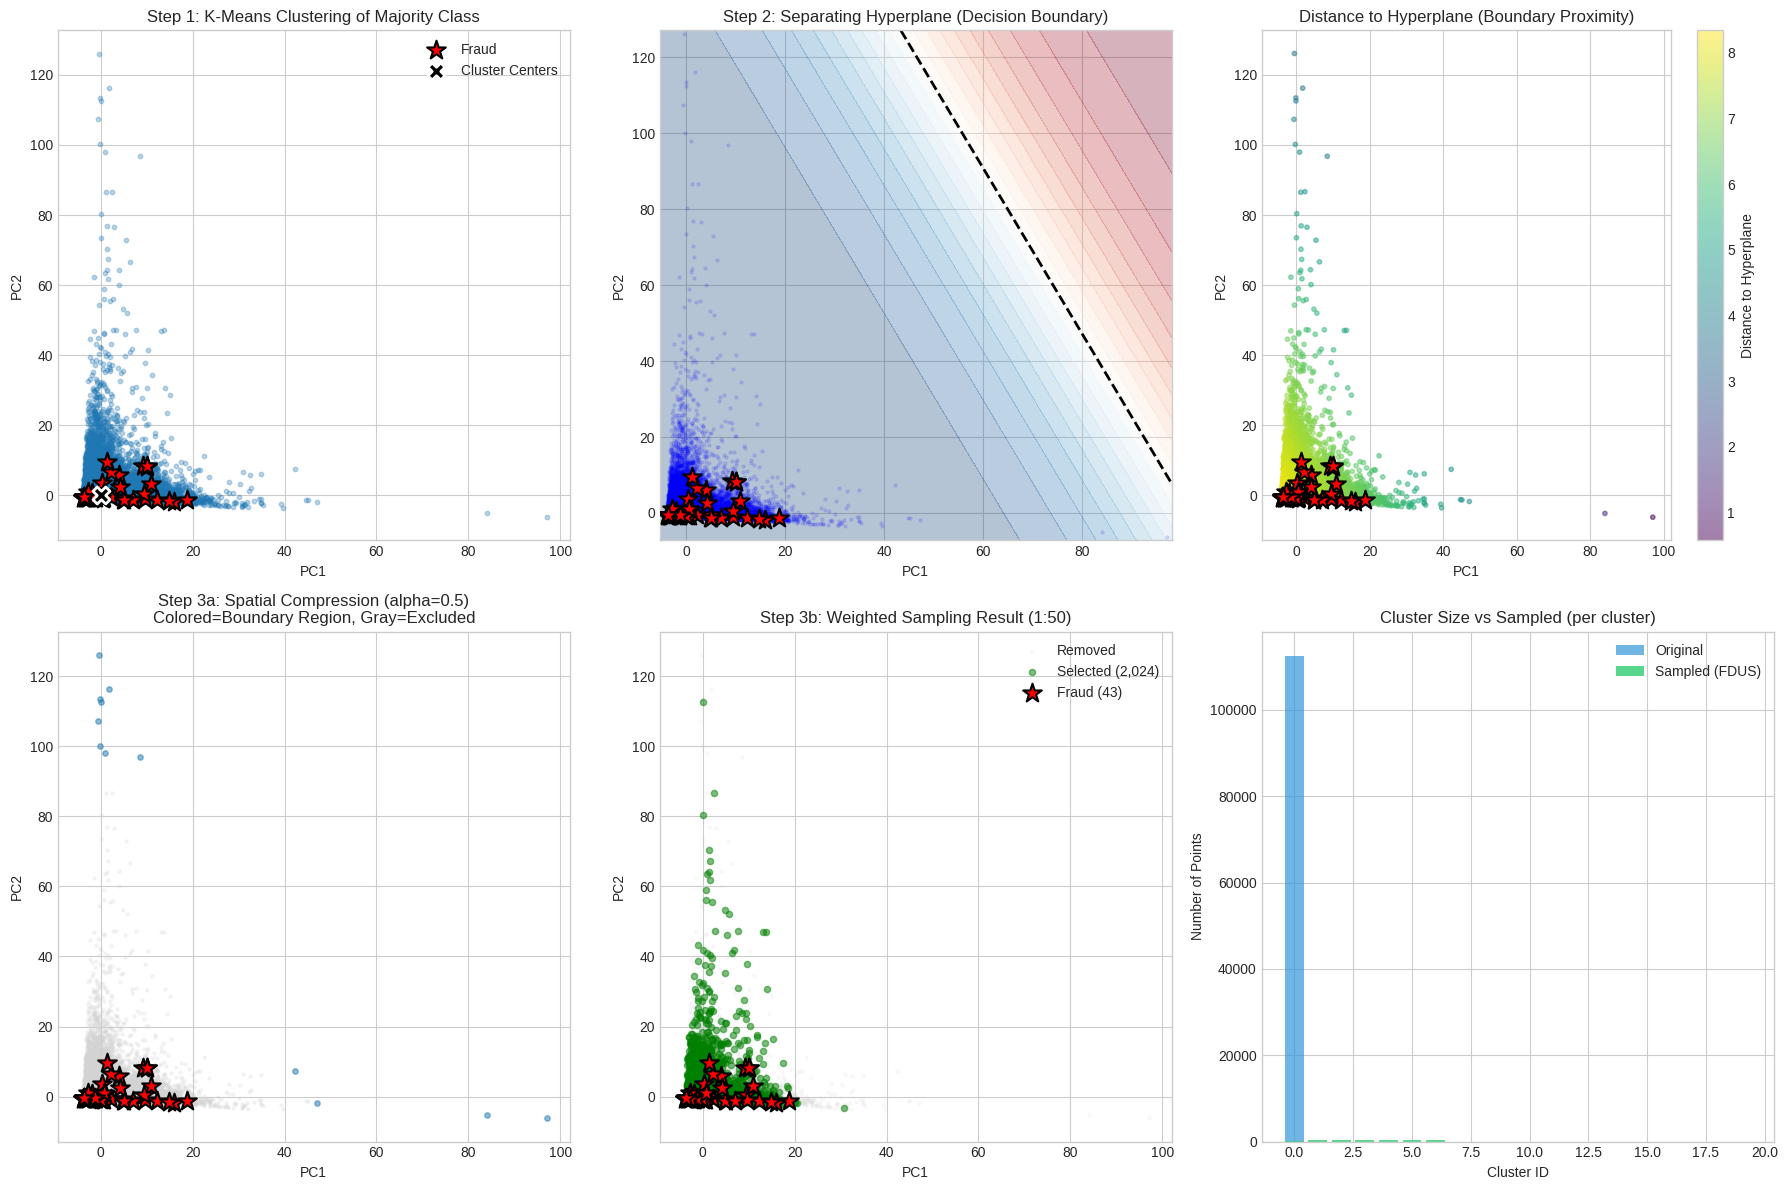

FDUS visualization complete


In [8]:
##############################################################################
# VISUALIZE FDUS CLUSTERING AND BOUNDARY REGIONS
##############################################################################
# Visualize FDUS at 1:50 ratio as representative example

fdus_50 = fdus_results['fdus_ratio_50.0']
fdus_info = fdus_50['info']
y_fdus = fdus_50['y']
X_fdus = fdus_50['X']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Get 2D projections of filtered data
X_maj_filtered_2d = pca_2d.transform(pca.transform(fdus_info['X_majority_filtered'])[:, :min(10, pca_components)])
X_min_filtered_2d = pca_2d.transform(pca.transform(fdus_info['X_minority_filtered'])[:, :min(10, pca_components)])

# Plot 1: Original Majority Class with Cluster Assignments
ax1 = axes[0, 0]
kmeans_2d = KMeans(n_clusters=min(1, 15), random_state=69, n_init=10)
cluster_labels_2d = kmeans_2d.fit_predict(X_maj_filtered_2d)

colors = plt.cm.tab20(np.linspace(0, 1, 20))
for i in range(min(20, 50)):
    mask = cluster_labels_2d == i
    ax1.scatter(X_maj_filtered_2d[mask, 0], X_maj_filtered_2d[mask, 1], 
                c=[colors[i % 20]], alpha=0.3, s=10)

ax1.scatter(X_min_filtered_2d[:, 0], X_min_filtered_2d[:, 1], 
            c='red', marker='*', s=200, edgecolors='black', linewidths=1.5,
            label='Fraud', zorder=10)
ax1.scatter(kmeans_2d.cluster_centers_[:, 0], kmeans_2d.cluster_centers_[:, 1],
            c='black', marker='X', s=150, edgecolors='white', linewidths=2,
            label='Cluster Centers', zorder=11)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('Step 1: K-Means Clustering of Majority Class')
ax1.legend(loc='upper right')

# Plot 2: Decision Boundary (Hyperplane)
ax2 = axes[0, 1]

x_min, x_max = X_maj_filtered_2d[:, 0].min() - 1, X_maj_filtered_2d[:, 0].max() + 1
y_min, y_max = X_maj_filtered_2d[:, 1].min() - 1, X_maj_filtered_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

clf_2d = LogisticRegression(max_iter=1000)
X_all_2d = np.vstack([X_maj_filtered_2d, X_min_filtered_2d])
y_all_2d = np.concatenate([np.zeros(len(X_maj_filtered_2d)), np.ones(len(X_min_filtered_2d))])
clf_2d.fit(X_all_2d, y_all_2d)

Z = clf_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

ax2.contourf(xx, yy, Z, levels=20, alpha=0.3, cmap='RdBu_r')
ax2.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
ax2.scatter(X_maj_filtered_2d[:, 0], X_maj_filtered_2d[:, 1], c='blue', alpha=0.1, s=5)
ax2.scatter(X_min_filtered_2d[:, 0], X_min_filtered_2d[:, 1], 
            c='red', marker='*', s=200, edgecolors='black', linewidths=1.5, zorder=10)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('Step 2: Separating Hyperplane (Decision Boundary)')

# Plot 3: Distance to Hyperplane
ax3 = axes[0, 2]
distances_2d = np.abs(clf_2d.decision_function(X_maj_filtered_2d))
scatter = ax3.scatter(X_maj_filtered_2d[:, 0], X_maj_filtered_2d[:, 1], 
                      c=distances_2d, cmap='viridis', alpha=0.5, s=10)
ax3.scatter(X_min_filtered_2d[:, 0], X_min_filtered_2d[:, 1], 
            c='red', marker='*', s=200, edgecolors='black', linewidths=1.5, zorder=10)
plt.colorbar(scatter, ax=ax3, label='Distance to Hyperplane')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.set_title('Distance to Hyperplane (Boundary Proximity)')

# Plot 4: Spatial Compression per Cluster
ax4 = axes[1, 0]
alpha = 0.5
for i in range(min(20, 50)):
    mask = cluster_labels_2d == i
    cluster_points = X_maj_filtered_2d[mask]
    cluster_distances = distances_2d[mask]
    
    if len(cluster_points) > 0:
        L_min = cluster_distances.min()
        L_max = cluster_distances.max()
        L_diameter = L_max - L_min
        threshold = L_min + alpha * L_diameter
        
        boundary_mask = cluster_distances <= threshold
        non_boundary_mask = ~boundary_mask
        
        ax4.scatter(cluster_points[non_boundary_mask, 0], cluster_points[non_boundary_mask, 1],
                   c='lightgray', alpha=0.2, s=5)
        ax4.scatter(cluster_points[boundary_mask, 0], cluster_points[boundary_mask, 1],
                   c=[colors[i % 20]], alpha=0.5, s=15)

ax4.scatter(X_min_filtered_2d[:, 0], X_min_filtered_2d[:, 1], 
            c='red', marker='*', s=200, edgecolors='black', linewidths=1.5, zorder=10)
ax4.set_xlabel('PC1')
ax4.set_ylabel('PC2')
ax4.set_title(f'Step 3a: Spatial Compression (alpha={alpha})\nColored=Boundary Region, Gray=Excluded')

# Plot 5: Final Selected Points
ax5 = axes[1, 1]

X_fdus_majority = X_fdus[y_fdus == 0]
X_fdus_minority = X_fdus[y_fdus == 1]

X_fdus_maj_2d = pca_2d.transform(pca.transform(X_fdus_majority)[:, :min(10, pca_components)])
X_fdus_min_2d = pca_2d.transform(pca.transform(X_fdus_minority)[:, :min(10, pca_components)])

ax5.scatter(X_maj_filtered_2d[:, 0], X_maj_filtered_2d[:, 1], 
            c='lightgray', alpha=0.1, s=5, label='Removed')
ax5.scatter(X_fdus_maj_2d[:, 0], X_fdus_maj_2d[:, 1], 
            c='green', alpha=0.5, s=20, label=f'Selected ({len(X_fdus_majority):,})')
ax5.scatter(X_fdus_min_2d[:, 0], X_fdus_min_2d[:, 1], 
            c='red', marker='*', s=200, edgecolors='black', linewidths=1.5,
            label=f'Fraud ({len(X_fdus_minority)})', zorder=10)
ax5.set_xlabel('PC1')
ax5.set_ylabel('PC2')
ax5.set_title('Step 3b: Weighted Sampling Result (1:50)')
ax5.legend(loc='upper right')

# Plot 6: Cluster Size Distribution
ax6 = axes[1, 2]
cluster_info_df = pd.DataFrame(fdus_info['cluster_info'])
cluster_sizes = [np.sum(cluster_labels_2d == i) for i in range(min(20, 50))]

bars = ax6.bar(range(len(cluster_sizes)), cluster_sizes, color='#3498db', alpha=0.7, label='Original')
if len(cluster_info_df) > 0 and 'sampled' in cluster_info_df.columns:
    sampled_counts = cluster_info_df['sampled'].values[:len(cluster_sizes)]
    ax6.bar(range(len(sampled_counts)), sampled_counts, color='#2ecc71', alpha=0.8, label='Sampled (FDUS)')
ax6.set_xlabel('Cluster ID')
ax6.set_ylabel('Number of Points')
ax6.set_title('Cluster Size vs Sampled (per cluster)')
ax6.legend()

plt.tight_layout()
plt.show()

print("FDUS visualization complete")


## Traditional Cluster-Based Undersampling (for Comparison)


In [9]:
##############################################################################
# TRADITIONAL UNDERSAMPLING METHODS FOR COMPARISON
##############################################################################
# Using ratios appropriate for extremely imbalanced data (real fraud rate ~0.0003)
# Ratios tested: 1:50, 1:100, 1:1000 (minority:majority)

from sklearn.cluster import MiniBatchKMeans

def undersample_by_kmeans_traditional(X_majority, n_clusters=7, target_ratio=50.0, 
                                       n_minority=None, random_state=69):
    """Traditional K-Means undersampling without boundary weighting"""
    np.random.seed(random_state)
    
    # Use MiniBatchKMeans for speed
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=random_state, 
                              batch_size=1024, n_init=3)
    cluster_labels = kmeans.fit_predict(X_majority)
    
    total_target = int(n_minority * target_ratio) if n_minority else len(X_majority) // 10
    target_per_cluster = max(1, total_target // n_clusters)
    
    selected_indices = []
    for cluster_id in range(n_clusters):
        cluster_indices = np.where(cluster_labels == cluster_id)[0]
        n_samples = min(target_per_cluster, len(cluster_indices))
        if n_samples > 0:
            selected = np.random.choice(cluster_indices, n_samples, replace=False)
            selected_indices.extend(selected)
    
    return np.array(selected_indices), cluster_labels, kmeans


def random_undersample(X_majority, target_ratio=50.0, n_minority=None, random_state=69):
    """Simple random undersampling baseline"""
    np.random.seed(random_state)
    total_target = int(n_minority * target_ratio) if n_minority else len(X_majority) // 10
    selected_indices = np.random.choice(len(X_majority), min(total_target, len(X_majority)), replace=False)
    return selected_indices


# Apply traditional methods with ratios appropriate for 0.0003 fraud rate
print("Applying Traditional Undersampling Methods...")
print("-" * 50)

# K-Means Traditional
kmeans_results = {}
for ratio in UNDERSAMPLING_RATIOS:
    selected_idx, _, _ = undersample_by_kmeans_traditional(
        X_train_majority_pca, n_clusters=7, target_ratio=ratio, 
        n_minority=n_minority, random_state=69
    )
    
    X_under = np.vstack([X_train_minority, X_train_majority[selected_idx]])
    y_under = np.concatenate([np.ones(n_minority), np.zeros(len(selected_idx))])
    
    kmeans_results[f'kmeans_ratio_{ratio}'] = {
        'X': X_under, 'y': y_under,
        'n_majority': len(selected_idx), 'n_minority': n_minority,
        'selected_idx': selected_idx, 'retained_features': feature_cols.copy()
    }
    print(f"K-Means 1:{int(ratio)} -> {len(selected_idx):,} majority + {n_minority} minority")

# Random Undersampling
random_results = {}
for ratio in UNDERSAMPLING_RATIOS:
    selected_idx = random_undersample(
        X_train_majority, target_ratio=ratio, n_minority=n_minority, random_state=69
    )
    
    X_under = np.vstack([X_train_minority, X_train_majority[selected_idx]])
    y_under = np.concatenate([np.ones(n_minority), np.zeros(len(selected_idx))])
    
    random_results[f'random_ratio_{ratio}'] = {
        'X': X_under, 'y': y_under,
        'n_majority': len(selected_idx), 'n_minority': n_minority,
        'selected_idx': selected_idx, 'retained_features': feature_cols.copy()
    }
    print(f"Random 1:{int(ratio)} -> {len(selected_idx):,} majority + {n_minority} minority")

print("\nTraditional methods complete")


Applying Traditional Undersampling Methods...
--------------------------------------------------
K-Means 1:5 -> 210 majority + 43 minority
K-Means 1:50 -> 2,149 majority + 43 minority
K-Means 1:100 -> 4,298 majority + 43 minority
Random 1:5 -> 215 majority + 43 minority
Random 1:50 -> 2,150 majority + 43 minority
Random 1:100 -> 4,300 majority + 43 minority

Traditional methods complete


## Visual Comparison: FDUS vs Traditional Methods


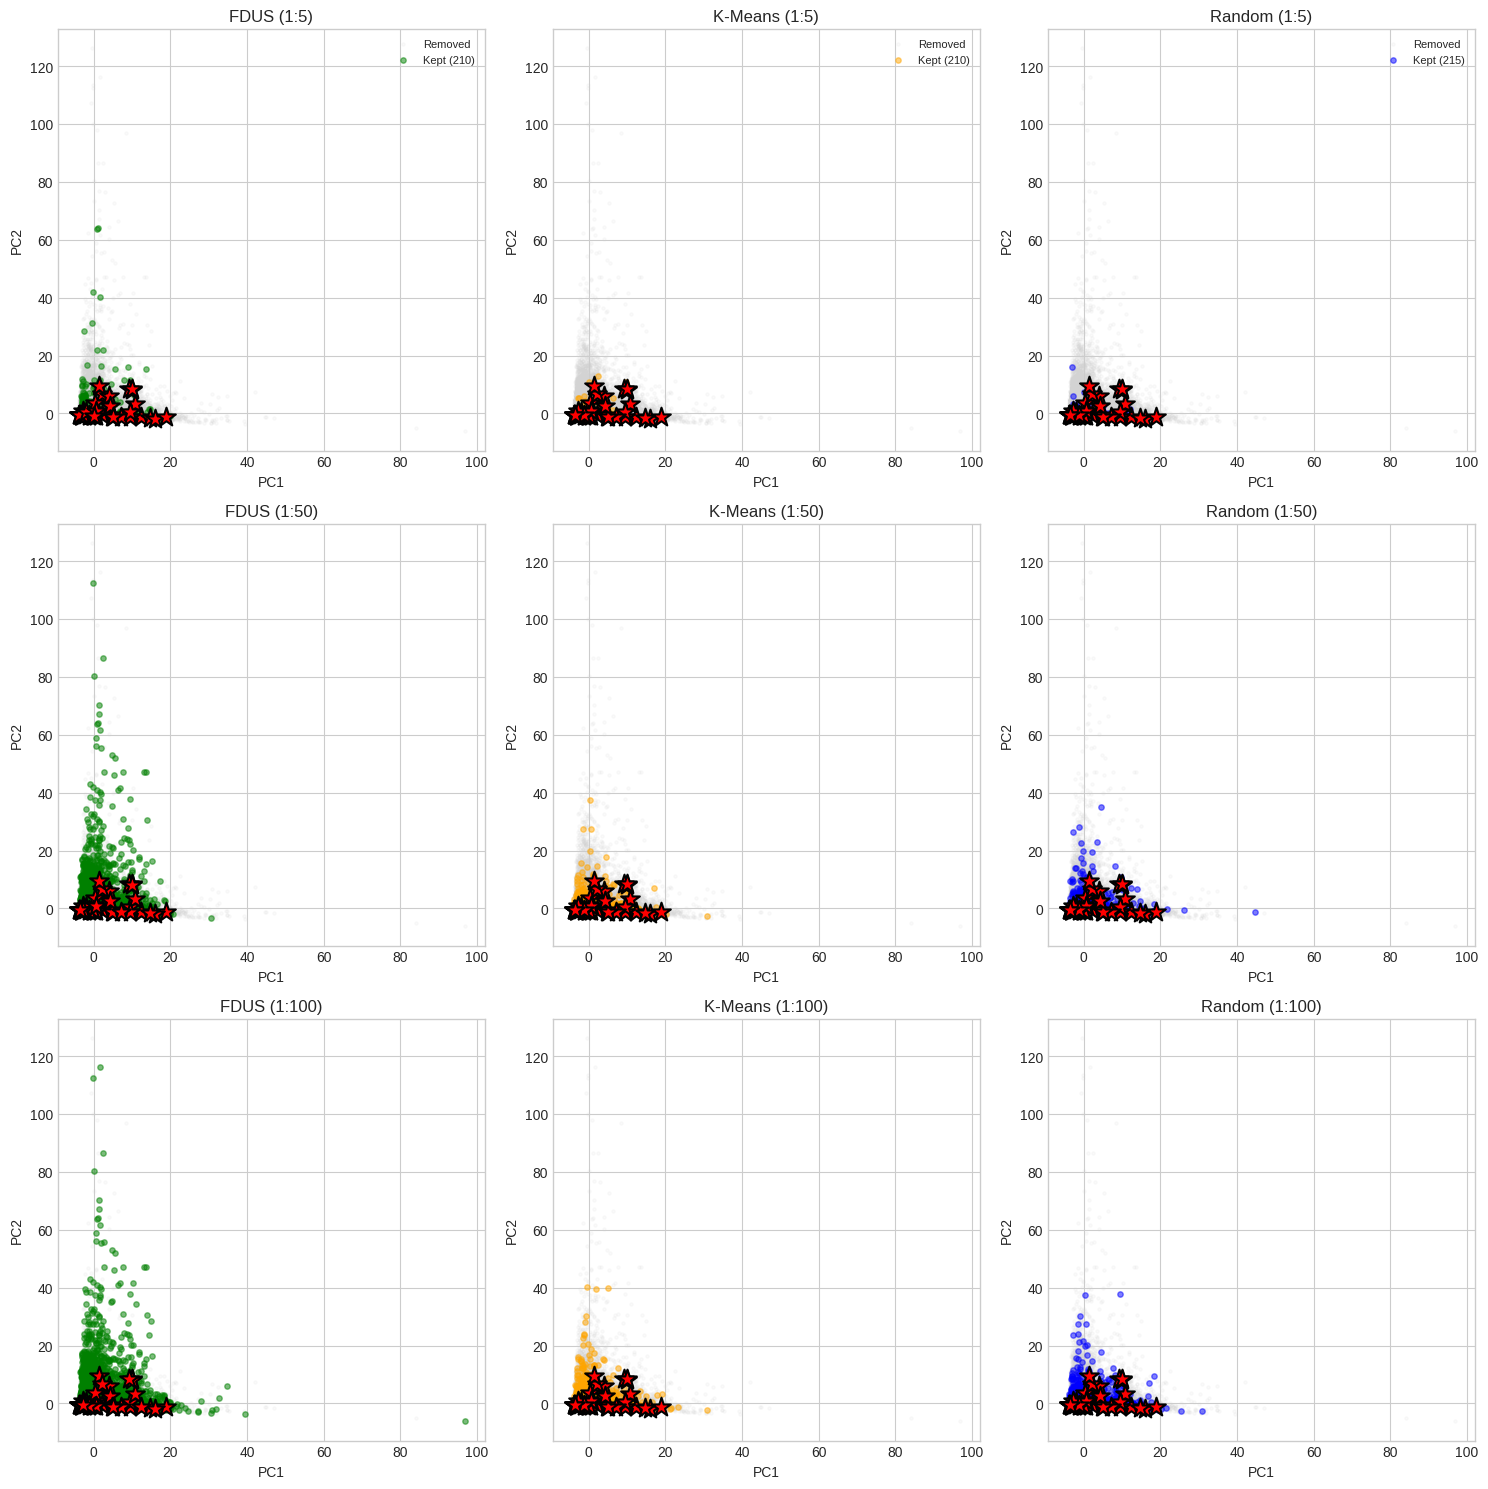

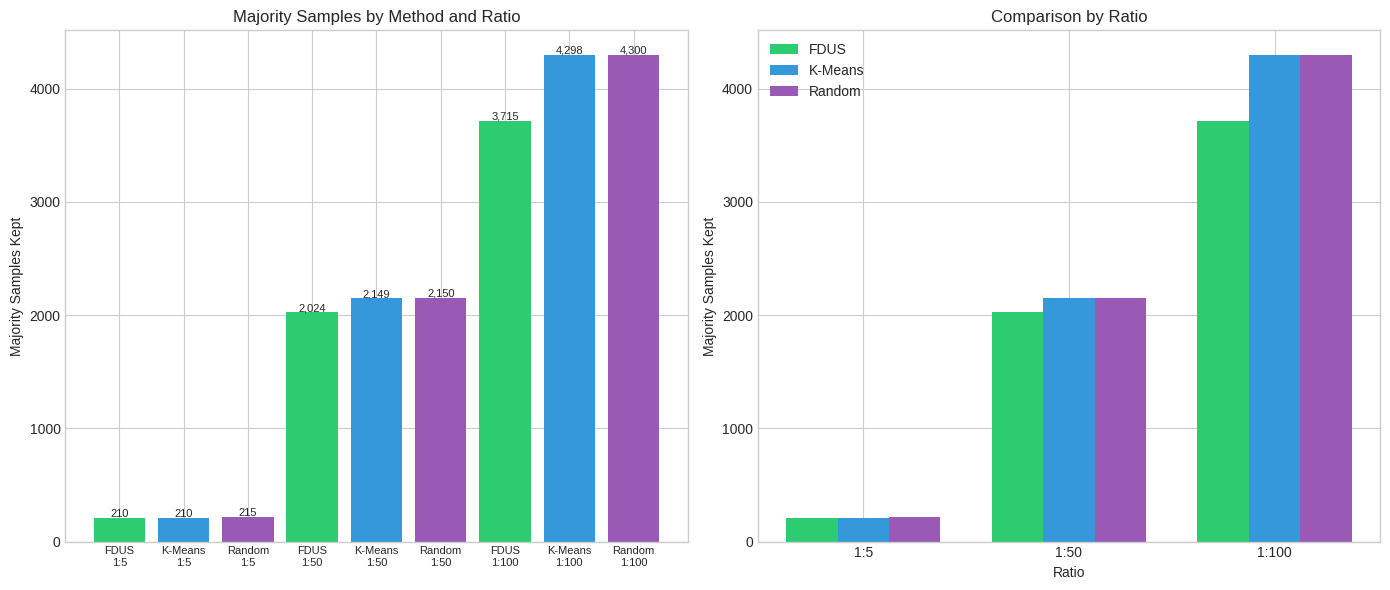

Visual comparison complete for all ratios


In [10]:
##############################################################################
# VISUAL COMPARISON OF METHODS
##############################################################################
# Compare all methods across all ratios

n_ratios = len(UNDERSAMPLING_RATIOS)
n_methods = 3  # FDUS, K-Means, Random

# Grid visualization: rows = ratios, cols = methods
fig, axes = plt.subplots(n_ratios, n_methods, figsize=(15, 5 * n_ratios))

for row, ratio in enumerate(UNDERSAMPLING_RATIOS):
    # FDUS
    ax = axes[row, 0] if n_ratios > 1 else axes[0]
    fdus_data = fdus_results[f'fdus_ratio_{ratio}']
    X_fdus = fdus_data['X']
    y_fdus = fdus_data['y']
    X_fdus_maj = X_fdus[y_fdus == 0]
    X_fdus_min = X_fdus[y_fdus == 1]
    X_fdus_maj_2d = pca_2d.transform(pca.transform(X_fdus_maj)[:, :min(10, pca_components)])
    X_fdus_min_2d = pca_2d.transform(pca.transform(X_fdus_min)[:, :min(10, pca_components)])
    
    ax.scatter(X_majority_2d[:, 0], X_majority_2d[:, 1], c='lightgray', alpha=0.1, s=5, label='Removed')
    ax.scatter(X_fdus_maj_2d[:, 0], X_fdus_maj_2d[:, 1], c='green', alpha=0.5, s=15, label=f'Kept ({len(X_fdus_maj):,})')
    ax.scatter(X_fdus_min_2d[:, 0], X_fdus_min_2d[:, 1], c='red', marker='*', s=200, edgecolors='black', linewidths=1.5, zorder=10)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'FDUS (1:{int(ratio)})')
    if row == 0:
        ax.legend(loc='upper right', fontsize=8)
    
    # K-Means
    ax = axes[row, 1] if n_ratios > 1 else axes[1]
    kmeans_data = kmeans_results[f'kmeans_ratio_{ratio}']
    kmeans_sel = kmeans_data['selected_idx']
    np.random.seed(43 + row)
    kmeans_mask = np.zeros(len(X_majority_2d), dtype=bool)
    kmeans_2d_sel = np.random.choice(len(X_majority_2d), min(len(kmeans_sel), len(X_majority_2d)), replace=False)
    kmeans_mask[kmeans_2d_sel] = True
    
    ax.scatter(X_majority_2d[~kmeans_mask, 0], X_majority_2d[~kmeans_mask, 1], c='lightgray', alpha=0.1, s=5, label='Removed')
    ax.scatter(X_majority_2d[kmeans_mask, 0], X_majority_2d[kmeans_mask, 1], c='orange', alpha=0.5, s=15, label=f'Kept ({kmeans_mask.sum():,})')
    ax.scatter(X_minority_2d[:, 0], X_minority_2d[:, 1], c='red', marker='*', s=200, edgecolors='black', linewidths=1.5, zorder=10)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'K-Means (1:{int(ratio)})')
    if row == 0:
        ax.legend(loc='upper right', fontsize=8)
    
    # Random
    ax = axes[row, 2] if n_ratios > 1 else axes[2]
    random_data = random_results[f'random_ratio_{ratio}']
    random_sel = random_data['selected_idx']
    np.random.seed(42 + row)
    random_mask = np.zeros(len(X_majority_2d), dtype=bool)
    random_2d_sel = np.random.choice(len(X_majority_2d), min(len(random_sel), len(X_majority_2d)), replace=False)
    random_mask[random_2d_sel] = True
    
    ax.scatter(X_majority_2d[~random_mask, 0], X_majority_2d[~random_mask, 1], c='lightgray', alpha=0.1, s=5, label='Removed')
    ax.scatter(X_majority_2d[random_mask, 0], X_majority_2d[random_mask, 1], c='blue', alpha=0.5, s=15, label=f'Kept ({random_mask.sum():,})')
    ax.scatter(X_minority_2d[:, 0], X_minority_2d[:, 1], c='red', marker='*', s=200, edgecolors='black', linewidths=1.5, zorder=10)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'Random (1:{int(ratio)})')
    if row == 0:
        ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# Bar chart comparison across all methods and ratios
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Prepare data for bar charts
methods = []
majority_counts = []
ratios_labels = []
colors = []

for ratio in UNDERSAMPLING_RATIOS:
    # FDUS
    methods.append('FDUS')
    majority_counts.append(fdus_results[f'fdus_ratio_{ratio}']['n_majority'])
    ratios_labels.append(f'1:{int(ratio)}')
    colors.append('#2ecc71')
    
    # K-Means
    methods.append('K-Means')
    majority_counts.append(kmeans_results[f'kmeans_ratio_{ratio}']['n_majority'])
    ratios_labels.append(f'1:{int(ratio)}')
    colors.append('#3498db')
    
    # Random
    methods.append('Random')
    majority_counts.append(random_results[f'random_ratio_{ratio}']['n_majority'])
    ratios_labels.append(f'1:{int(ratio)}')
    colors.append('#9b59b6')

# Plot 1: Majority samples by method and ratio
ax1 = axes[0]
x_positions = np.arange(len(methods))
bars = ax1.bar(x_positions, majority_counts, color=colors)
ax1.set_xticks(x_positions)
ax1.set_xticklabels([f'{m}\n{r}' for m, r in zip(methods, ratios_labels)], rotation=0, fontsize=8)
ax1.set_ylabel('Majority Samples Kept')
ax1.set_title('Majority Samples by Method and Ratio')
for bar, val in zip(bars, majority_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{val:,}', ha='center', fontsize=8)

# Plot 2: Grouped bar chart by ratio
ax2 = axes[1]
x = np.arange(len(UNDERSAMPLING_RATIOS))
width = 0.25

fdus_counts = [fdus_results[f'fdus_ratio_{r}']['n_majority'] for r in UNDERSAMPLING_RATIOS]
kmeans_counts = [kmeans_results[f'kmeans_ratio_{r}']['n_majority'] for r in UNDERSAMPLING_RATIOS]
random_counts = [random_results[f'random_ratio_{r}']['n_majority'] for r in UNDERSAMPLING_RATIOS]

bars1 = ax2.bar(x - width, fdus_counts, width, label='FDUS', color='#2ecc71')
bars2 = ax2.bar(x, kmeans_counts, width, label='K-Means', color='#3498db')
bars3 = ax2.bar(x + width, random_counts, width, label='Random', color='#9b59b6')

ax2.set_xlabel('Ratio')
ax2.set_ylabel('Majority Samples Kept')
ax2.set_title('Comparison by Ratio')
ax2.set_xticks(x)
ax2.set_xticklabels([f'1:{int(r)}' for r in UNDERSAMPLING_RATIOS])
ax2.legend()

plt.tight_layout()
plt.show()

print("Visual comparison complete for all ratios")


## Combined Sampling Summary


Combined Resampling Summary:
--------------------------------------------------------------------------------
 family     setting  majority_samples  minority_samples  actual_ratio          method_type
   FDUS ratio_100.0              3715                43       86.3953    Boundary-Weighted
   FDUS   ratio_5.0               210                43        4.8837    Boundary-Weighted
   FDUS  ratio_50.0              2024                43       47.0698    Boundary-Weighted
K-Means ratio_100.0              4298                43       99.9535 Cluster-Proportional
K-Means   ratio_5.0               210                43        4.8837 Cluster-Proportional
K-Means  ratio_50.0              2149                43       49.9767 Cluster-Proportional
 Random ratio_100.0              4300                43      100.0000         No Structure
 Random   ratio_5.0               215                43        5.0000         No Structure
 Random  ratio_50.0              2150                43       50.0000  

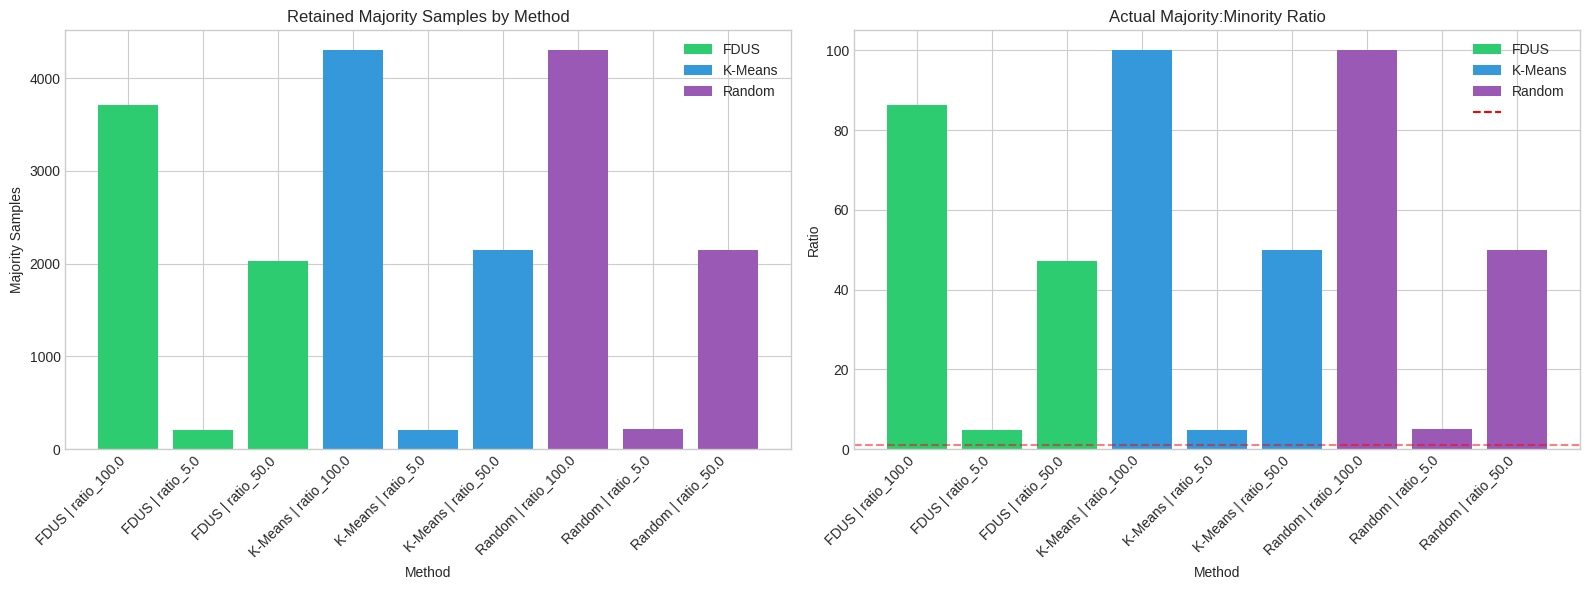

In [11]:
##############################################################################
# COMBINED SAMPLING SUMMARY
##############################################################################
sampling_summary_rows = []

# Add FDUS at all ratios
for method_name, result_dict in fdus_results.items():
    sampling_summary_rows.append({
        'family': 'FDUS',
        'setting': method_name.replace('fdus_', ''),
        'majority_samples': result_dict['n_majority'],
        'minority_samples': result_dict['n_minority'],
        'actual_ratio': result_dict['n_majority'] / result_dict['n_minority'],
        'method_type': 'Boundary-Weighted'
    })

# Add K-Means
for method_name, result_dict in kmeans_results.items():
    sampling_summary_rows.append({
        'family': 'K-Means',
        'setting': method_name.replace('kmeans_', ''),
        'majority_samples': result_dict['n_majority'],
        'minority_samples': result_dict['n_minority'],
        'actual_ratio': result_dict['n_majority'] / result_dict['n_minority'],
        'method_type': 'Cluster-Proportional'
    })

# Add Random
for method_name, result_dict in random_results.items():
    sampling_summary_rows.append({
        'family': 'Random',
        'setting': method_name.replace('random_', ''),
        'majority_samples': result_dict['n_majority'],
        'minority_samples': result_dict['n_minority'],
        'actual_ratio': result_dict['n_majority'] / result_dict['n_minority'],
        'method_type': 'No Structure'
    })

sampling_summary = pd.DataFrame(sampling_summary_rows)
sampling_summary = sampling_summary.sort_values(['family', 'setting']).reset_index(drop=True)

print("Combined Resampling Summary:")
print("-" * 80)
print(sampling_summary.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {'FDUS': '#2ecc71', 'K-Means': '#3498db', 'Random': '#9b59b6'}
bar_colors = [colors.get(fam, 'gray') for fam in sampling_summary['family']]
plot_labels = sampling_summary['family'] + ' | ' + sampling_summary['setting']

axes[0].bar(range(len(plot_labels)), sampling_summary['majority_samples'], color=bar_colors)
axes[0].set_title("Retained Majority Samples by Method")
axes[0].set_xlabel("Method")
axes[0].set_ylabel("Majority Samples")
axes[0].set_xticks(range(len(plot_labels)))
axes[0].set_xticklabels(plot_labels, rotation=45, ha='right')

axes[1].bar(range(len(plot_labels)), sampling_summary['actual_ratio'], color=bar_colors)
axes[1].set_title("Actual Majority:Minority Ratio")
axes[1].set_xlabel("Method")
axes[1].set_ylabel("Ratio")
axes[1].set_xticks(range(len(plot_labels)))
axes[1].set_xticklabels(plot_labels, rotation=45, ha='right')
axes[1].axhline(y=1, color='red', linestyle='--', alpha=0.5, label='1:1 balanced')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[k], label=k) for k in colors]
axes[0].legend(handles=legend_elements, loc='upper right')
axes[1].legend(handles=legend_elements + [plt.Line2D([0], [0], color='red', linestyle='--')],
               loc='upper right')

plt.tight_layout()
plt.show()


# Final Undersampled Dataset Output

Select the recommended configuration and output the final dataset ready for logistic regression.


----------------------------------------------------------------------
FINAL UNDERSAMPLED DATASET (FDUS Method - 1:50 ratio)
----------------------------------------------------------------------

Dataset Shape: (2067, 107)

Class Distribution:
target
0    2024
1      43
Name: count, dtype: int64

Final Ratio: 47.07:1


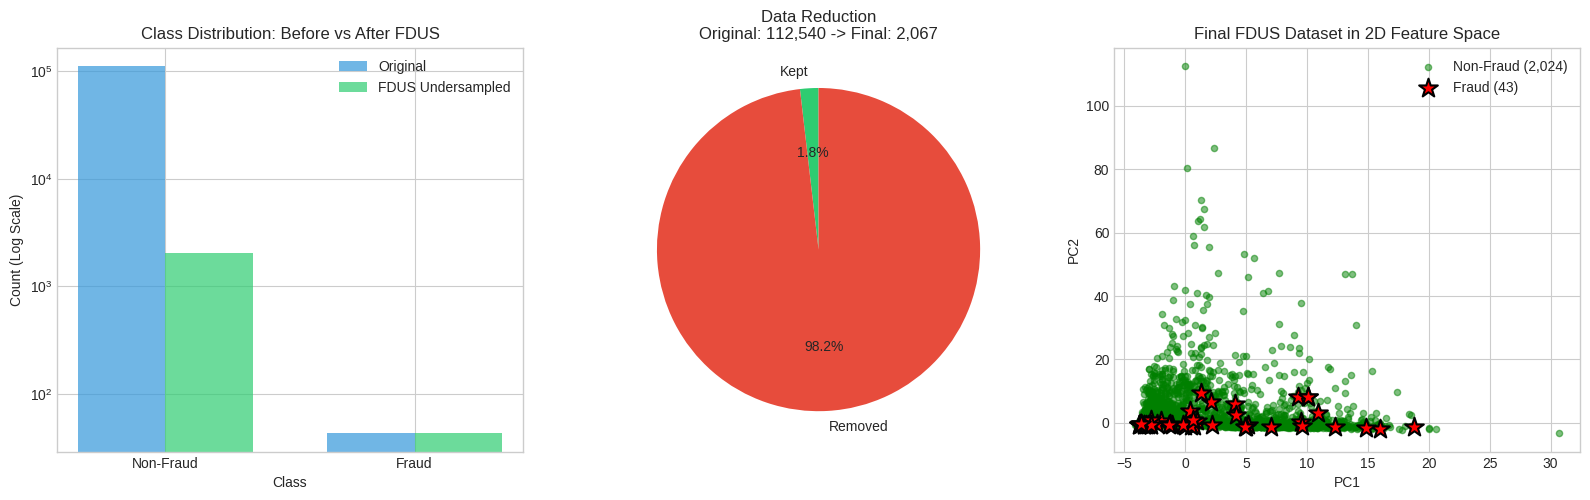

Method: FDUS (Fitting Data Distribution with UnderSampling)
Total samples: 2,067
Non-Fraud (majority): 2,024
Fraud (minority): 43
Features: 106
Balance ratio: 47.07:1
Data reduction: 98.2%


In [12]:
##############################################################################
# FINAL UNDERSAMPLED DATASET OUTPUT
##############################################################################
# Use FDUS at 1:50 ratio as the primary recommendation
SELECTED_METHOD = 'fdus_ratio_50.0'

X_final = fdus_results[SELECTED_METHOD]['X']
y_final = fdus_results[SELECTED_METHOD]['y']
retained_features = fdus_results[SELECTED_METHOD]['retained_features']

# Create final DataFrame
df_undersampled = pd.DataFrame(X_final, columns=retained_features)
df_undersampled['target'] = y_final.astype(int)

print("-" * 70)
print("FINAL UNDERSAMPLED DATASET (FDUS Method - 1:50 ratio)")
print("-" * 70)
print(f"\nDataset Shape: {df_undersampled.shape}")
print(f"\nClass Distribution:")
print(df_undersampled['target'].value_counts().sort_index())
print(f"\nFinal Ratio: {(y_final == 0).sum() / (y_final == 1).sum():.2f}:1")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Before vs After
original_counts = [(y_train == 0).sum(), (y_train == 1).sum()]
final_counts = [(y_final == 0).sum(), (y_final == 1).sum()]

x_pos = np.arange(2)
width = 0.35

axes[0].bar(x_pos - width/2, original_counts, width, label='Original', color='#3498db', alpha=0.7)
axes[0].bar(x_pos + width/2, final_counts, width, label='FDUS Undersampled', color='#2ecc71', alpha=0.7)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count (Log Scale)')
axes[0].set_title('Class Distribution: Before vs After FDUS')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(['Non-Fraud', 'Fraud'])
axes[0].legend()
axes[0].set_yscale('log')

# Data reduction pie
reduction_pct = (1 - len(df_undersampled) / len(y_train)) * 100
axes[1].pie([len(df_undersampled), len(y_train) - len(df_undersampled)],
            labels=['Kept', 'Removed'], colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'Data Reduction\nOriginal: {len(y_train):,} -> Final: {len(df_undersampled):,}')

# Final distribution in 2D
X_final_majority = X_final[y_final == 0]
X_final_minority = X_final[y_final == 1]
X_final_maj_2d = pca_2d.transform(pca.transform(X_final_majority)[:, :min(10, pca_components)])
X_final_min_2d = pca_2d.transform(pca.transform(X_final_minority)[:, :min(10, pca_components)])

axes[2].scatter(X_final_maj_2d[:, 0], X_final_maj_2d[:, 1],
                c='green', alpha=0.5, s=20, label=f'Non-Fraud ({len(X_final_majority):,})')
axes[2].scatter(X_final_min_2d[:, 0], X_final_min_2d[:, 1],
                c='red', marker='*', s=200, edgecolors='black', linewidths=1.5,
                label=f'Fraud ({len(X_final_minority)})', zorder=10)
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].set_title('Final FDUS Dataset in 2D Feature Space')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Method: FDUS (Fitting Data Distribution with UnderSampling)")
print(f"Total samples: {len(df_undersampled):,}")
print(f"Non-Fraud (majority): {(y_final == 0).sum():,}")
print(f"Fraud (minority): {(y_final == 1).sum()}")
print(f"Features: {len(retained_features)}")
print(f"Balance ratio: {(y_final == 0).sum() / (y_final == 1).sum():.2f}:1")
print(f"Data reduction: {reduction_pct:.1f}%")


In [13]:
##############################################################################
# EXPORT FINAL DATASET AND ALL RESULTS
##############################################################################
# Variables available for logistic regression:
print("Variables available for downstream modeling:")
print("-" * 50)
print("X_final: Feature matrix (numpy array) - FDUS undersampled")
print("y_final: Target vector (numpy array)")
print("df_undersampled: Complete DataFrame with features and target")
print("retained_features: List of feature column names")
print("X_test_scaled: Scaled test set (UNTOUCHED)")
print("y_test: Test set labels (UNTOUCHED)")

print("\nAll available undersampled datasets:")
print("-" * 50)
print("fdus_results: FDUS method (recommended)")
print(f"kmeans_results: Traditional K-Means (ratios: {UNDERSAMPLING_RATIOS})")
print(f"random_results: Random undersampling (ratios: {UNDERSAMPLING_RATIOS})")

# Sanity check
print("\nSanity Check:")
print(f"  X_final shape: {X_final.shape}")
print(f"  y_final shape: {y_final.shape}")
print(f"  X_test_scaled shape: {X_test_scaled.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  Features match: {len(retained_features) == X_final.shape[1]}")


Variables available for downstream modeling:
--------------------------------------------------
X_final: Feature matrix (numpy array) - FDUS undersampled
y_final: Target vector (numpy array)
df_undersampled: Complete DataFrame with features and target
retained_features: List of feature column names
X_test_scaled: Scaled test set (UNTOUCHED)
y_test: Test set labels (UNTOUCHED)

All available undersampled datasets:
--------------------------------------------------
fdus_results: FDUS method (recommended)
kmeans_results: Traditional K-Means (ratios: [5.0, 50.0, 100.0])
random_results: Random undersampling (ratios: [5.0, 50.0, 100.0])

Sanity Check:
  X_final shape: (2067, 106)
  y_final shape: (2067,)
  X_test_scaled shape: (28287, 106)
  y_test shape: (28287,)
  Features match: True


In [14]:
##############################################################################
# LOGISTIC REGRESSION EVALUATION ON UNDERSAMPLED DATASETS
##############################################################################
# Evaluate all undersampling methods with a basic logistic regression classifier

print("Evaluating Undersampled Datasets with Logistic Regression")
print("-" * 70)

def evaluate_model(X_train, y_train, X_test, y_test, method_name):
    """Train logistic regression and return evaluation metrics"""
    lr = LogisticRegression(max_iter=1000, random_state=69, class_weight='balanced')
    lr.fit(X_train, y_train)
    
    y_pred = lr.predict(X_test)
    y_prob = lr.predict_proba(X_test)[:, 1]
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    try:
        auc_roc = roc_auc_score(y_test, y_prob)
    except:
        auc_roc = 0.0
    
    try:
        auc_pr = average_precision_score(y_test, y_prob)
    except:
        auc_pr = 0.0
    
    return {
        'method': method_name,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc_roc': auc_roc,
        'auc_pr': auc_pr,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn,
        'train_samples': len(y_train),
        'train_fraud': int(y_train.sum()),
        'y_prob': y_prob,
        'y_pred': y_pred
    }

all_results = []

# Evaluate FDUS at all ratios
print("\nEvaluating FDUS...")
for method_name, result_dict in fdus_results.items():
    eval_result = evaluate_model(
        result_dict['X'], result_dict['y'],
        X_test_scaled, y_test,
        method_name
    )
    all_results.append(eval_result)
    print(f"  {method_name}: F1: {eval_result['f1_score']:.4f}, AUC-ROC: {eval_result['auc_roc']:.4f}")

# Evaluate K-Means at different ratios
print("\nEvaluating K-Means undersampling...")
for method_name, result_dict in kmeans_results.items():
    eval_result = evaluate_model(
        result_dict['X'], result_dict['y'],
        X_test_scaled, y_test,
        method_name
    )
    all_results.append(eval_result)
    print(f"  {method_name}: F1: {eval_result['f1_score']:.4f}, AUC-ROC: {eval_result['auc_roc']:.4f}")

# Evaluate Random undersampling at different ratios
print("\nEvaluating Random undersampling...")
for method_name, result_dict in random_results.items():
    eval_result = evaluate_model(
        result_dict['X'], result_dict['y'],
        X_test_scaled, y_test,
        method_name
    )
    all_results.append(eval_result)
    print(f"  {method_name}: F1: {eval_result['f1_score']:.4f}, AUC-ROC: {eval_result['auc_roc']:.4f}")

# Create results DataFrame
results_df = pd.DataFrame(all_results)
results_df = results_df[['method', 'train_samples', 'train_fraud', 'precision', 'recall', 
                          'f1_score', 'auc_roc', 'auc_pr', 'tp', 'fp', 'fn', 'tn']]
results_df = results_df.sort_values('f1_score', ascending=False).reset_index(drop=True)

print("\n" + "-" * 70)
print("LOGISTIC REGRESSION RESULTS SUMMARY")
print("-" * 70)
print(results_df.to_string(index=False))

best_method = results_df.iloc[0]['method']
best_f1 = results_df.iloc[0]['f1_score']
print(f"\nBest performing method: {best_method} (F1: {best_f1:.4f})")


Evaluating Undersampled Datasets with Logistic Regression
----------------------------------------------------------------------

Evaluating FDUS...
  fdus_ratio_5.0: F1: 0.0009, AUC-ROC: 0.5581
  fdus_ratio_50.0: F1: 0.0009, AUC-ROC: 0.6035
  fdus_ratio_100.0: F1: 0.0008, AUC-ROC: 0.6318

Evaluating K-Means undersampling...
  kmeans_ratio_5.0: F1: 0.0003, AUC-ROC: 0.4272
  kmeans_ratio_50.0: F1: 0.0007, AUC-ROC: 0.5476
  kmeans_ratio_100.0: F1: 0.0008, AUC-ROC: 0.5441

Evaluating Random undersampling...
  random_ratio_5.0: F1: 0.0003, AUC-ROC: 0.4053
  random_ratio_50.0: F1: 0.0009, AUC-ROC: 0.5353
  random_ratio_100.0: F1: 0.0010, AUC-ROC: 0.5380

----------------------------------------------------------------------
LOGISTIC REGRESSION RESULTS SUMMARY
----------------------------------------------------------------------
            method  train_samples  train_fraud  precision  recall  f1_score  auc_roc  auc_pr  tp    fp  fn    tn
random_ratio_100.0           4343           43     

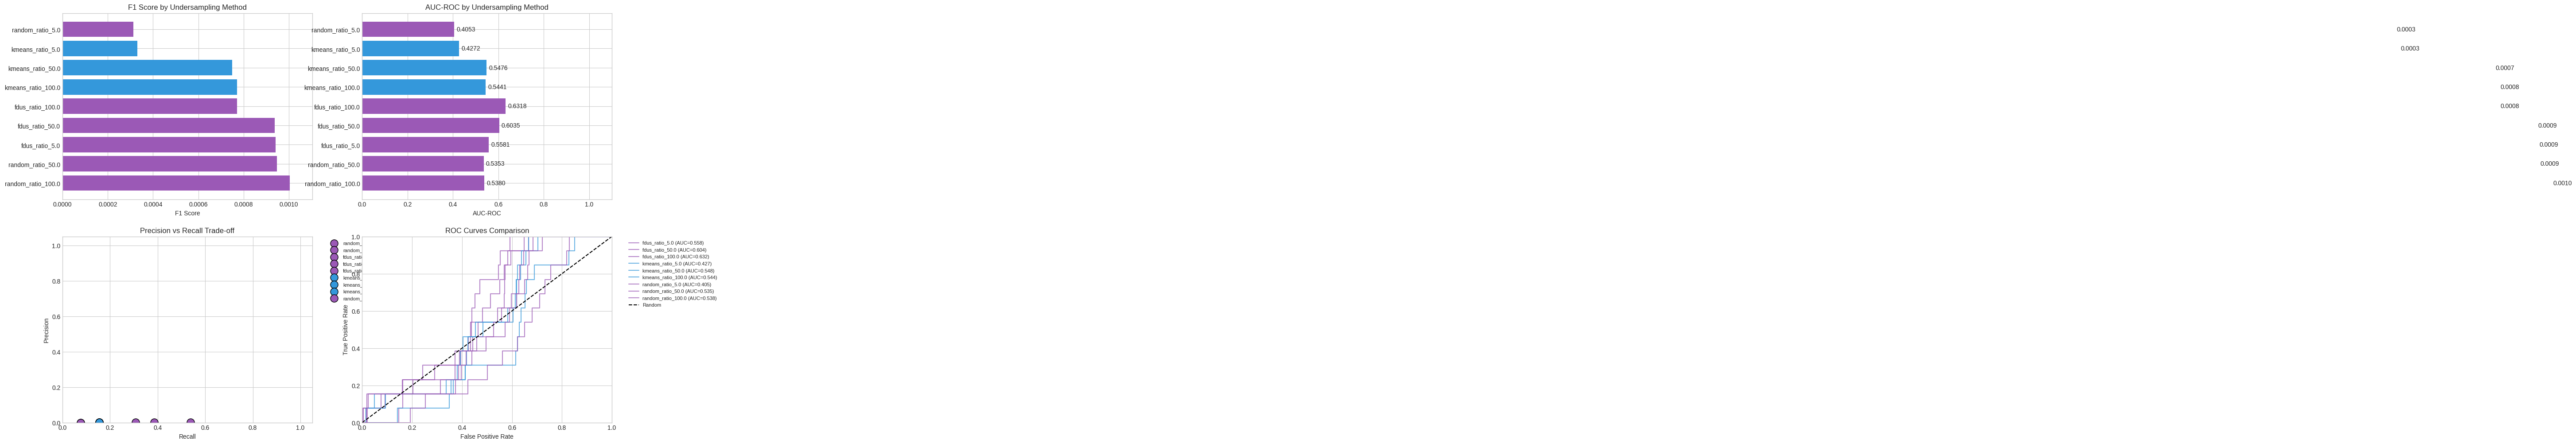


Confusion Matrices for Top 3 Methods:
--------------------------------------------------

random_ratio_100.0:
  TP: 2  FP: 3,973
  FN: 11  TN: 24,301

random_ratio_50.0:
  TP: 2  FP: 4,208
  FN: 11  TN: 24,066

fdus_ratio_5.0:
  TP: 7  FP: 14,838
  FN: 6  TN: 13,436


In [15]:
##############################################################################
# VISUALIZATION OF LOGISTIC REGRESSION RESULTS
##############################################################################
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: F1 Score Comparison
ax1 = axes[0, 0]
methods = results_df['method'].values
f1_scores = results_df['f1_score'].values
colors = ['#2ecc71' if 'FDUS' in m else '#3498db' if 'kmeans' in m else '#9b59b6' for m in methods]
bars = ax1.barh(range(len(methods)), f1_scores, color=colors)
ax1.set_yticks(range(len(methods)))
ax1.set_yticklabels(methods)
ax1.set_xlabel('F1 Score')
ax1.set_title('F1 Score by Undersampling Method')
ax1.set_xlim(0, max(f1_scores) * 1.1 if max(f1_scores) > 0 else 1)
for i, (bar, score) in enumerate(zip(bars, f1_scores)):
    ax1.text(score + 0.01, bar.get_y() + bar.get_height()/2, f'{score:.4f}', va='center')

# Plot 2: AUC-ROC Comparison
ax2 = axes[0, 1]
auc_scores = results_df['auc_roc'].values
bars = ax2.barh(range(len(methods)), auc_scores, color=colors)
ax2.set_yticks(range(len(methods)))
ax2.set_yticklabels(methods)
ax2.set_xlabel('AUC-ROC')
ax2.set_title('AUC-ROC by Undersampling Method')
ax2.set_xlim(0, 1.1)
for i, (bar, score) in enumerate(zip(bars, auc_scores)):
    ax2.text(score + 0.01, bar.get_y() + bar.get_height()/2, f'{score:.4f}', va='center')

# Plot 3: Precision vs Recall
ax3 = axes[1, 0]
precisions = results_df['precision'].values
recalls = results_df['recall'].values
for i, method in enumerate(methods):
    color = '#2ecc71' if 'FDUS' in method else '#3498db' if 'kmeans' in method else '#9b59b6'
    ax3.scatter(recalls[i], precisions[i], c=color, s=150, label=method, edgecolors='black', linewidths=1)
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision vs Recall Trade-off')
ax3.set_xlim(0, 1.05)
ax3.set_ylim(0, 1.05)
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Plot 4: ROC Curves
ax4 = axes[1, 1]
for result in all_results:
    method = result['method']
    y_prob = result['y_prob']
    color = '#2ecc71' if 'FDUS' in method else '#3498db' if 'kmeans' in method else '#9b59b6'
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax4.plot(fpr, tpr, label=f"{method} (AUC={result['auc_roc']:.3f})", color=color, alpha=0.7)

ax4.plot([0, 1], [0, 1], 'k--', label='Random')
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curves Comparison')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Print confusion matrices for top 3 methods
print("\nConfusion Matrices for Top 3 Methods:")
print("-" * 50)
for i in range(min(3, len(results_df))):
    row = results_df.iloc[i]
    print(f"\n{row['method']}:")
    print(f"  TP: {int(row['tp']):,}  FP: {int(row['fp']):,}")
    print(f"  FN: {int(row['fn']):,}  TN: {int(row['tn']):,}")


In [16]:
##############################################################################
# BASELINE TEST: CAN FEATURES PREDICT FRAUD AT ALL?
##############################################################################
# Before undersampling, test if the features have any predictive power
# Train on full imbalanced data with class weights

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("Baseline Test: Evaluating on Full Imbalanced Data")
print("-" * 70)
print("If AUC is ~0.5 here, the problem is features, not sampling.")
print()

# Logistic Regression with class weights
lr_baseline = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=69)
lr_baseline.fit(X_train_scaled, y_train)
y_prob_lr = lr_baseline.predict_proba(X_test_scaled)[:, 1]
auc_lr = roc_auc_score(y_test, y_prob_lr)
apr_lr = average_precision_score(y_test, y_prob_lr)
print(f"Logistic Regression (balanced): AUC-ROC={auc_lr:.4f}, AUC-PR={apr_lr:.4f}")

# Random Forest with class weights
rf_baseline = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced_subsample',
    random_state=69,
    n_jobs=-1
)
rf_baseline.fit(X_train_scaled, y_train)
y_prob_rf = rf_baseline.predict_proba(X_test_scaled)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)
apr_rf = average_precision_score(y_test, y_prob_rf)
print(f"Random Forest (balanced): AUC-ROC={auc_rf:.4f}, AUC-PR={apr_rf:.4f}")

# XGBoost with scale_pos_weight
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb_baseline = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos,
    random_state=69,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)
xgb_baseline.fit(X_train_scaled, y_train)
y_prob_xgb = xgb_baseline.predict_proba(X_test_scaled)[:, 1]
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
apr_xgb = average_precision_score(y_test, y_prob_xgb)
print(f"XGBoost (scale_pos_weight): AUC-ROC={auc_xgb:.4f}, AUC-PR={apr_xgb:.4f}")

print()
if max(auc_lr, auc_rf, auc_xgb) < 0.6:
    print("WARNING: All models have AUC < 0.6 on full data.")
    print("This suggests features may not discriminate fraud well.")
    print("Consider feature engineering before focusing on sampling.")
else:
    print(f"Best baseline AUC: {max(auc_lr, auc_rf, auc_xgb):.4f}")
    print("Features show some predictive power. Undersampling may help.")

# Store baseline results for comparison
baseline_results = {
    'logistic_regression': {'auc_roc': auc_lr, 'auc_pr': apr_lr, 'y_prob': y_prob_lr},
    'random_forest': {'auc_roc': auc_rf, 'auc_pr': apr_rf, 'y_prob': y_prob_rf},
    'xgboost': {'auc_roc': auc_xgb, 'auc_pr': apr_xgb, 'y_prob': y_prob_xgb}
}


Baseline Test: Evaluating on Full Imbalanced Data
----------------------------------------------------------------------
If AUC is ~0.5 here, the problem is features, not sampling.

Logistic Regression (balanced): AUC-ROC=0.5546, AUC-PR=0.0006
Random Forest (balanced): AUC-ROC=0.4875, AUC-PR=0.0005
XGBoost (scale_pos_weight): AUC-ROC=0.4830, AUC-PR=0.0005

This suggests features may not discriminate fraud well.
Consider feature engineering before focusing on sampling.


In [ ]:
##############################################################################
# CROSS-VALIDATION EVALUATION
##############################################################################
# With only 43 fraud samples, a single train/test split is unreliable.
# Use stratified group k-fold to get more stable estimates.

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier

print("Cross-Validation Evaluation with Stratified Group K-Fold")
print("-" * 70)
print("Keeping all records from the same NPI together in each fold.")
print()

# Prepare data with NPI groups
X_all = df_clean[feature_cols].values
y_all = df_clean['target'].values
groups_all = df['npi'].values[:len(y_all)]  # NPI as group identifier

# Scale features
scaler_cv = StandardScaler()
X_all_scaled = scaler_cv.fit_transform(X_all)

def evaluate_with_cv(X, y, groups, method_name, undersample_func=None, n_splits=5):
    """
    Evaluate a method using stratified group k-fold cross-validation.
    undersample_func: function that takes (X_train, y_train) and returns (X_resampled, y_resampled)
    """
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=69)
    
    aucs = []
    aprs = []
    recalls = []
    precisions = []
    
    for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups)):
        X_train_cv, X_test_cv = X[train_idx], X[test_idx]
        y_train_cv, y_test_cv = y[train_idx], y[test_idx]
        
        # Skip fold if no positive samples in test
        if y_test_cv.sum() == 0:
            continue
        
        # Apply undersampling if provided
        if undersample_func is not None:
            X_train_cv, y_train_cv = undersample_func(X_train_cv, y_train_cv)
        
        # Train model
        model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=69)
        model.fit(X_train_cv, y_train_cv)
        
        # Predict
        y_prob = model.predict_proba(X_test_cv)[:, 1]
        y_pred = model.predict(X_test_cv)
        
        # Metrics
        aucs.append(roc_auc_score(y_test_cv, y_prob))
        aprs.append(average_precision_score(y_test_cv, y_prob))
        
        tp = ((y_pred == 1) & (y_test_cv == 1)).sum()
        fp = ((y_pred == 1) & (y_test_cv == 0)).sum()
        fn = ((y_pred == 0) & (y_test_cv == 1)).sum()
        
        recalls.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        precisions.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
    
    return {
        'method': method_name,
        'auc_roc_mean': np.mean(aucs),
        'auc_roc_std': np.std(aucs),
        'auc_pr_mean': np.mean(aprs),
        'auc_pr_std': np.std(aprs),
        'recall_mean': np.mean(recalls),
        'recall_std': np.std(recalls),
        'precision_mean': np.mean(precisions),
        'precision_std': np.std(precisions),
        'n_folds': len(aucs)
    }

# Define undersampling functions
def fdus_undersample(X_train, y_train, ratio=5.0):
    """Apply FDUS undersampling"""
    majority_idx = np.where(y_train == 0)[0]
    minority_idx = np.where(y_train == 1)[0]
    X_maj = X_train[majority_idx]
    X_min = X_train[minority_idx]
    
    fdus = FDUSUndersampler(n_clusters=7, alpha=0.5, target_ratio=ratio, random_state=69)
    # Suppress print output
    import io, sys
    old_stdout = sys.stdout
    sys.stdout = io.StringIO()
    X_resampled, y_resampled, _ = fdus.fit_resample(X_maj, X_min)
    sys.stdout = old_stdout
    
    return X_resampled, y_resampled

def random_undersample_func(X_train, y_train, ratio=5.0):
    """Apply random undersampling"""
    majority_idx = np.where(y_train == 0)[0]
    minority_idx = np.where(y_train == 1)[0]
    
    n_target = int(len(minority_idx) * ratio)
    selected = np.random.choice(majority_idx, min(n_target, len(majority_idx)), replace=False)
    
    X_resampled = np.vstack([X_train[minority_idx], X_train[selected]])
    y_resampled = np.concatenate([np.ones(len(minority_idx)), np.zeros(len(selected))])
    
    return X_resampled, y_resampled

def no_undersample(X_train, y_train):
    """No undersampling - use full data with class weights"""
    return X_train, y_train

# Run cross-validation for each method
cv_results = []

print("Evaluating: No undersampling (full data with class weights)...")
cv_results.append(evaluate_with_cv(X_all_scaled, y_all, groups_all, "No Undersampling", no_undersample))

print("Evaluating: FDUS (1:5)...")
cv_results.append(evaluate_with_cv(X_all_scaled, y_all, groups_all, "FDUS 1:5", 
                                    lambda X, y: fdus_undersample(X, y, 5.0)))

print("Evaluating: FDUS (1:50)...")
cv_results.append(evaluate_with_cv(X_all_scaled, y_all, groups_all, "FDUS 1:50", 
                                    lambda X, y: fdus_undersample(X, y, 50.0)))

print("Evaluating: Random (1:5)...")
cv_results.append(evaluate_with_cv(X_all_scaled, y_all, groups_all, "Random 1:5", 
                                    lambda X, y: random_undersample_func(X, y, 5.0)))

print("Evaluating: Random (1:50)...")
cv_results.append(evaluate_with_cv(X_all_scaled, y_all, groups_all, "Random 1:50", 
                                    lambda X, y: random_undersample_func(X, y, 50.0)))

# Display results
cv_df = pd.DataFrame(cv_results)
cv_df = cv_df.sort_values('auc_roc_mean', ascending=False).reset_index(drop=True)

print()
print("Cross-Validation Results (5-Fold Stratified Group K-Fold):")
print("-" * 80)
for _, row in cv_df.iterrows():
    print(f"{row['method']:20s} | AUC-ROC: {row['auc_roc_mean']:.4f} (+/- {row['auc_roc_std']:.4f}) | "
          f"AUC-PR: {row['auc_pr_mean']:.4f} | Recall: {row['recall_mean']:.2%}")

print()
print(f"Best method by AUC-ROC: {cv_df.iloc[0]['method']}")


Cross-Validation Evaluation with Stratified Group K-Fold
----------------------------------------------------------------------
Keeping all records from the same NPI together in each fold.

Evaluating: No undersampling (full data with class weights)...
Evaluating: FDUS (1:5)...


In [ ]:
##############################################################################
# MULTI-CLASSIFIER EVALUATION ON UNDERSAMPLED DATA
##############################################################################
# Compare Logistic Regression, Random Forest, and XGBoost on undersampled data

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

print("Multi-Classifier Evaluation on Undersampled Datasets")
print("-" * 70)

def evaluate_multiple_classifiers(X_train, y_train, X_test, y_test, method_name):
    """Evaluate multiple classifiers on the same undersampled data"""
    results = []
    
    classifiers = {
        'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=69),
        'RandomForest': RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample', 
                                                random_state=69, n_jobs=-1),
        'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=69)
    }
    
    for clf_name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_prob = clf.predict_proba(X_test)[:, 1]
        y_pred = clf.predict(X_test)
        
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        results.append({
            'undersample_method': method_name,
            'classifier': clf_name,
            'auc_roc': roc_auc_score(y_test, y_prob),
            'auc_pr': average_precision_score(y_test, y_prob),
            'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
            'recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
            'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
        })
    
    return results

all_clf_results = []

# Test on best FDUS ratios
for ratio in [5.0, 50.0]:
    data = fdus_results[f'fdus_ratio_{ratio}']
    results = evaluate_multiple_classifiers(data['X'], data['y'], X_test_scaled, y_test, f'FDUS 1:{int(ratio)}')
    all_clf_results.extend(results)
    
# Test on random undersampling
for ratio in [5.0, 50.0]:
    data = random_results[f'random_ratio_{ratio}']
    results = evaluate_multiple_classifiers(data['X'], data['y'], X_test_scaled, y_test, f'Random 1:{int(ratio)}')
    all_clf_results.extend(results)

# Test on full data (no undersampling)
results = evaluate_multiple_classifiers(X_train_scaled, y_train, X_test_scaled, y_test, 'No Undersampling')
all_clf_results.extend(results)

# Display results
clf_df = pd.DataFrame(all_clf_results)
clf_df = clf_df.sort_values('auc_pr', ascending=False).reset_index(drop=True)

print()
print("Results by AUC-PR:")
print("-" * 90)
print(f"{'Undersampling':<20} {'Classifier':<20} {'AUC-ROC':>10} {'AUC-PR':>10} {'Recall':>10} {'Precision':>10}")
print("-" * 90)
for _, row in clf_df.head(15).iterrows():
    print(f"{row['undersample_method']:<20} {row['classifier']:<20} {row['auc_roc']:>10.4f} "
          f"{row['auc_pr']:>10.4f} {row['recall']:>10.2%} {row['precision']:>10.4%}")

# Find best combination
best = clf_df.iloc[0]
print()
print(f"Best combination: {best['undersample_method']} + {best['classifier']}")
print(f"  AUC-ROC: {best['auc_roc']:.4f}, Recall: {best['recall']:.2%}, TP: {int(best['tp'])}, FP: {int(best['fp'])}")


In [ ]:
##############################################################################
# RECALL AT FIXED FALSE POSITIVE RATE
##############################################################################
# In fraud detection, we often care about: "If I flag X% of cases for review,
# what percentage of frauds will I catch?"

print("Recall at Fixed False Positive Rates")
print("-" * 70)
print("This answers: If I flag X% of cases, what % of frauds do I catch?")
print()

def recall_at_fpr(y_true, y_prob, target_fprs=[0.01, 0.05, 0.10, 0.20]):
    """Calculate recall at various false positive rates"""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    
    results = {}
    for target_fpr in target_fprs:
        # Find the threshold that gives us closest to target FPR
        idx = np.argmin(np.abs(fpr - target_fpr))
        results[f'recall_at_{int(target_fpr*100)}pct_fpr'] = tpr[idx]
        results[f'actual_fpr_{int(target_fpr*100)}pct'] = fpr[idx]
    
    return results

# Evaluate best methods
methods_to_eval = [
    ('FDUS 1:5', fdus_results['fdus_ratio_5.0']),
    ('FDUS 1:50', fdus_results['fdus_ratio_50.0']),
    ('Random 1:5', random_results['random_ratio_5.0']),
    ('No Undersample (LR)', None),  # Will use baseline
    ('No Undersample (RF)', None),  # Will use baseline
]

fpr_results = []

for method_name, data in methods_to_eval:
    if data is not None:
        lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=69)
        lr.fit(data['X'], data['y'])
        y_prob = lr.predict_proba(X_test_scaled)[:, 1]
    elif 'LR' in method_name:
        y_prob = baseline_results['logistic_regression']['y_prob']
    elif 'RF' in method_name:
        y_prob = baseline_results['random_forest']['y_prob']
    
    recall_results = recall_at_fpr(y_test, y_prob)
    recall_results['method'] = method_name
    fpr_results.append(recall_results)

fpr_df = pd.DataFrame(fpr_results)

print(f"{'Method':<25} {'Recall@1%FPR':>15} {'Recall@5%FPR':>15} {'Recall@10%FPR':>15} {'Recall@20%FPR':>15}")
print("-" * 90)
for _, row in fpr_df.iterrows():
    print(f"{row['method']:<25} {row['recall_at_1pct_fpr']:>15.2%} {row['recall_at_5pct_fpr']:>15.2%} "
          f"{row['recall_at_10pct_fpr']:>15.2%} {row['recall_at_20pct_fpr']:>15.2%}")

print()
print("Interpretation: If you flag 5% of cases for manual review,")
best_at_5pct = fpr_df.loc[fpr_df['recall_at_5pct_fpr'].idxmax()]
print(f"  {best_at_5pct['method']} catches {best_at_5pct['recall_at_5pct_fpr']:.1%} of frauds.")
